# Diabetes Risk Prediction
## Exploratory Data Analysis, Preprocessing, and Baseline Modeling
This notebook trains Random Forest and XGBoost on the preprocessed data from the EDA phase. We start with the raw unbalanced data as our baseline.

In [ ]:
import pandas as pd

df = pd.read_csv('Data/diabetes_012_health_indicators_BRFSS2015.csv')
df.head()

In [4]:
df.shape

(253680, 22)

In [5]:
df['Diabetes_012'].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [6]:
df['Diabetes_012'] = df['Diabetes_012'].apply(lambda x: 1 if x > 0 else 0)
df['Diabetes_012'].value_counts()

Diabetes_012
0    213703
1     39977
Name: count, dtype: int64

In [9]:
df.columns.tolist()

['Diabetes_012',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [10]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.157588,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.364355,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [11]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

This checks if any feature has more than 90% of people giving the same answer.

In [18]:
for col in df.columns:
    most_common_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    if most_common_pct > 90:
        print(f"{col}: {most_common_pct:.1f}% same value")

CholCheck: 96.3% same value
Stroke: 95.9% same value
HeartDiseaseorAttack: 90.6% same value
HvyAlcoholConsump: 94.4% same value
AnyHealthcare: 95.1% same value
NoDocbcCost: 91.6% same value


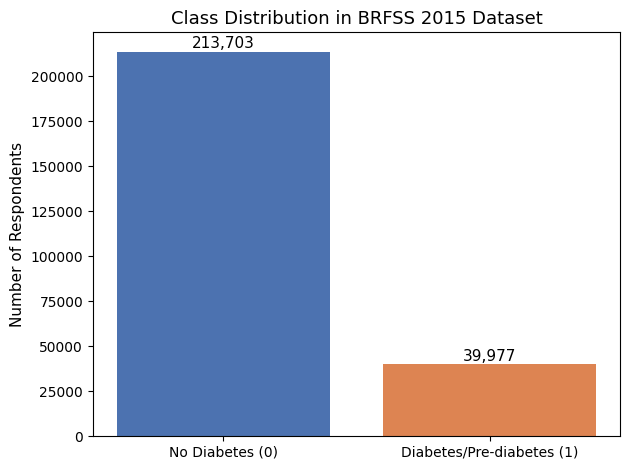

In [14]:
import matplotlib.pyplot as plt

counts = df['Diabetes_012'].value_counts()
colors = ['#4C72B0', '#DD8452']
bars = plt.bar(['No Diabetes (0)', 'Diabetes/Pre-diabetes (1)'], counts.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{int(bar.get_height()):,}', ha='center', fontsize=11)

plt.title('Class Distribution in BRFSS 2015 Dataset', fontsize=13)
plt.ylabel('Number of Respondents', fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
df.groupby('Diabetes_012').mean()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_012,,,,,,,,,,,,,,,,,,,,,
0,0.371132,0.379171,0.957104,27.742521,0.429680,0.031628,0.071833,0.779077,0.643023,0.821439,...,0.949739,0.079610,2.372391,2.944404,3.582416,0.132282,0.433985,7.786559,5.106629,6.208663
1,0.738350,0.664407,0.992421,31.802737,0.515271,0.088376,0.213673,0.636091,0.587388,0.757861,...,0.958076,0.108587,3.254446,4.469695,7.768417,0.360357,0.474323,9.344798,4.750031,5.226430


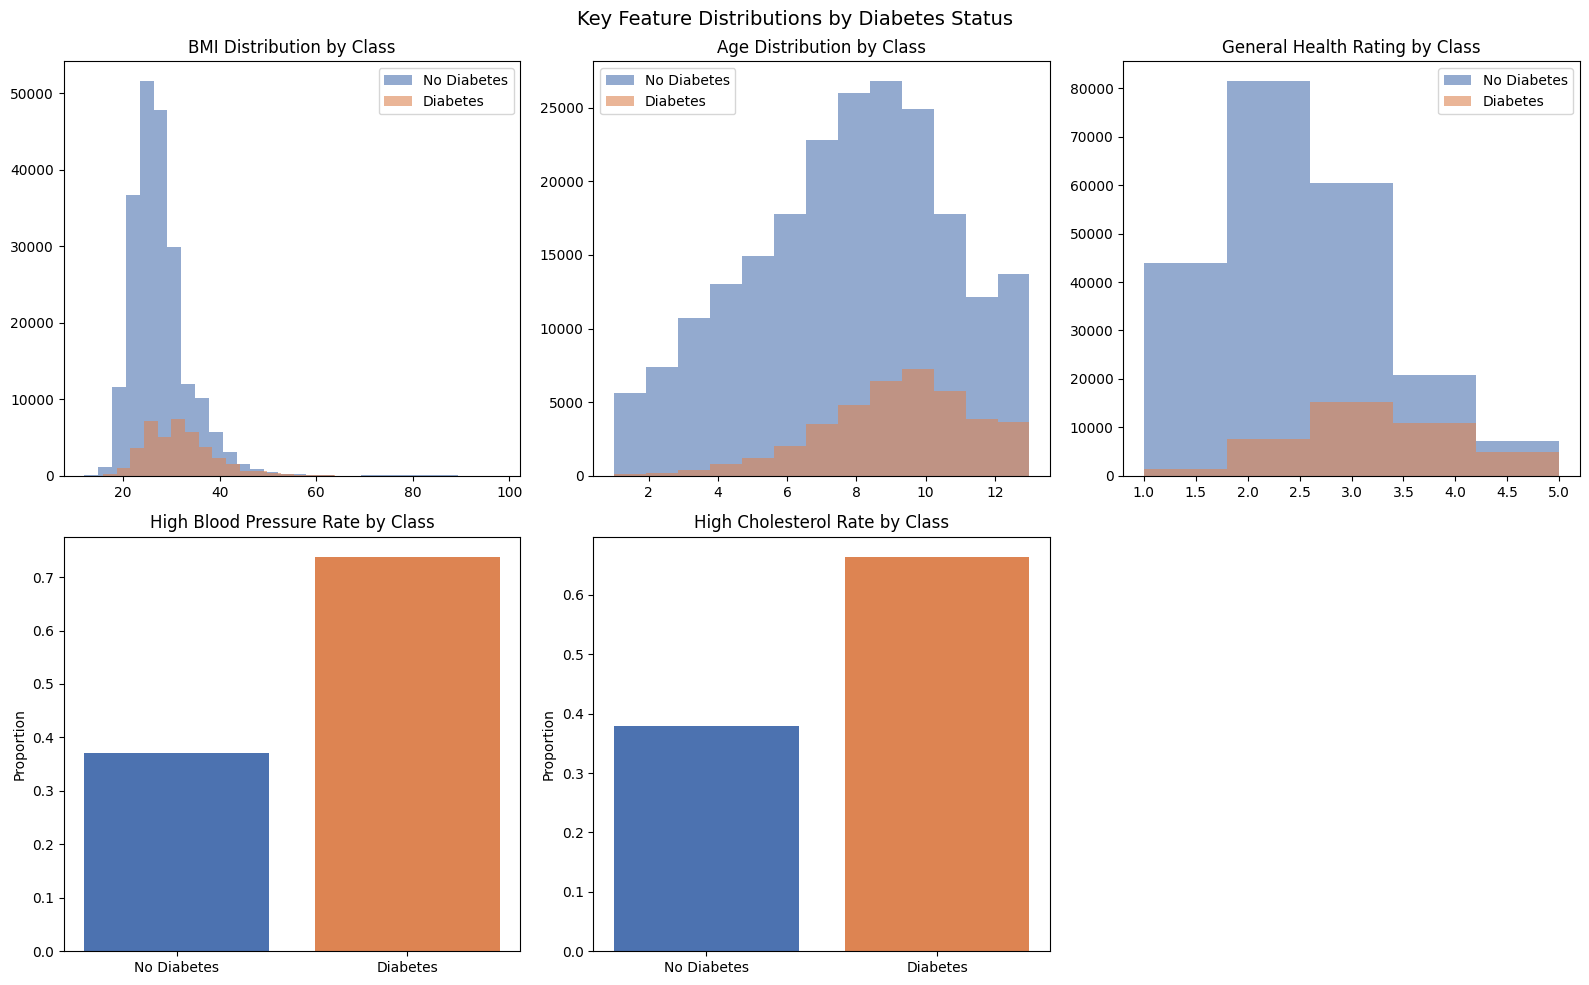

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# BMI distribution
axes[0,0].hist(df[df['Diabetes_012']==0]['BMI'], bins=30, alpha=0.6, label='No Diabetes', color='#4C72B0')
axes[0,0].hist(df[df['Diabetes_012']==1]['BMI'], bins=30, alpha=0.6, label='Diabetes', color='#DD8452')
axes[0,0].set_title('BMI Distribution by Class')
axes[0,0].legend()

# Age distribution
axes[0,1].hist(df[df['Diabetes_012']==0]['Age'], bins=13, alpha=0.6, label='No Diabetes', color='#4C72B0')
axes[0,1].hist(df[df['Diabetes_012']==1]['Age'], bins=13, alpha=0.6, label='Diabetes', color='#DD8452')
axes[0,1].set_title('Age Distribution by Class')
axes[0,1].legend()

# GenHlth distribution
axes[0,2].hist(df[df['Diabetes_012']==0]['GenHlth'], bins=5, alpha=0.6, label='No Diabetes', color='#4C72B0')
axes[0,2].hist(df[df['Diabetes_012']==1]['GenHlth'], bins=5, alpha=0.6, label='Diabetes', color='#DD8452')
axes[0,2].set_title('General Health Rating by Class')
axes[0,2].legend()

# HighBP by class
bp_data = df.groupby('Diabetes_012')['HighBP'].mean()
axes[1,0].bar(['No Diabetes', 'Diabetes'], bp_data.values, color=['#4C72B0', '#DD8452'])
axes[1,0].set_title('High Blood Pressure Rate by Class')
axes[1,0].set_ylabel('Proportion')

# HighChol by class
chol_data = df.groupby('Diabetes_012')['HighChol'].mean()
axes[1,1].bar(['No Diabetes', 'Diabetes'], chol_data.values, color=['#4C72B0', '#DD8452'])
axes[1,1].set_title('High Cholesterol Rate by Class')
axes[1,1].set_ylabel('Proportion')

# Hide the empty 6th subplot
axes[1,2].axis('off')

plt.suptitle('Key Feature Distributions by Diabetes Status', fontsize=14)
plt.tight_layout()
plt.show()

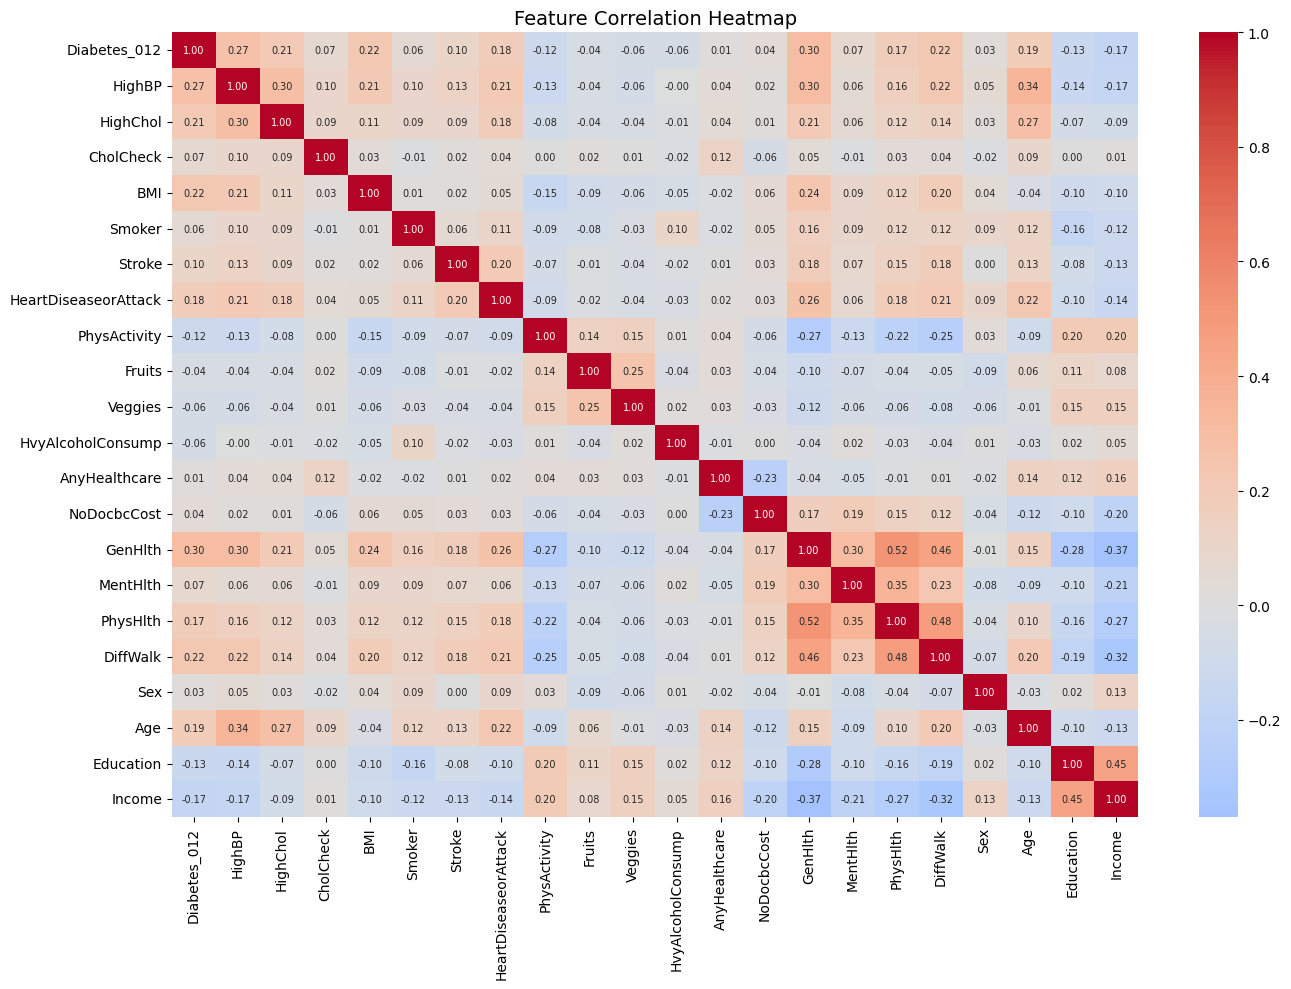

In [16]:
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## Preprocessing of the Data

In [19]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (253680, 21)
Target shape: (253680,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (202944, 21)
Test set: (50736, 21)

Training class distribution:
Diabetes_012
0    0.842
1    0.158
Name: proportion, dtype: float64

Test class distribution:
Diabetes_012
0    0.842
1    0.158
Name: proportion, dtype: float64


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - BMI first 5 values:", X_train['BMI'].values[:5])
print("After scaling - BMI first 5 values:", X_train_scaled[:5, X_train.columns.get_loc('BMI')].round(3))

Before scaling - BMI first 5 values: [28. 24. 50. 49. 27.]
After scaling - BMI first 5 values: [-0.059 -0.664  3.27   3.119 -0.21 ]


In [ ]:
import numpy as np

np.save('Data/X_train_scaled.npy', X_train_scaled)
np.save('Data/X_test_scaled.npy', X_test_scaled)
np.save('Data/y_train.npy', y_train.values)
np.save('Data/y_test.npy', y_test.values)

# Also save the feature names for later use
pd.DataFrame(X_train.columns).to_csv('Data/feature_names.csv', index=False)

# Save unscaled versions too for SHAP (SHAP works better with original values)
np.save('Data/X_train.npy', X_train.values)
np.save('Data/X_test.npy', X_test.values)

print("All files saved to Data/ folder:")
import os
for f in os.listdir('Data'):
    print(f" - {f}")

## Feature Importance: Correlation & Mutual Information

Two complementary methods for ranking features by their relationship with the diabetes target:

- **Pearson correlation** (absolute value): captures linear relationships — simple and interpretable.
- **Mutual information**: captures any statistical dependency (linear or non-linear) — more general.

Both analyses use the full training set to rank all 21 features.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

X_train_scaled = np.load('Data/X_train_scaled.npy')
X_train        = np.load('Data/X_train.npy')
y_train        = np.load('Data/y_train.npy')
feature_names  = pd.read_csv('Data/feature_names.csv').values.flatten().tolist()

corr = pd.DataFrame(X_train_scaled, columns=feature_names).corrwith(
       pd.Series(y_train)).abs().sort_values(ascending=False)
mi   = mutual_info_classif(X_train, y_train, random_state=42)
mi_s = pd.Series(mi, index=feature_names).sort_values(ascending=False)

print('Top 10 features by |Pearson correlation|:')
for f, v in corr.head(10).items():
    print(f'  {f:<25} {v:.4f}')
print('\nTop 10 features by Mutual Information:')
for f, v in mi_s.head(10).items():
    print(f'  {f:<25} {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_corr = corr.head(15)
axes[0].barh(top_corr.index[::-1], top_corr.values[::-1], color='#2196F3', alpha=0.85)
axes[0].set_title('Feature Correlation with Diabetes Target\n(absolute Pearson r)', fontsize=12)
axes[0].set_xlabel('|Correlation|', fontsize=11)

top_mi = mi_s.head(15)
axes[1].barh(top_mi.index[::-1], top_mi.values[::-1], color='#FF5722', alpha=0.85)
axes[1].set_title('Feature Importance — Mutual Information\nwith Diabetes Target', fontsize=12)
axes[1].set_xlabel('Mutual Information Score', fontsize=11)

plt.suptitle('Feature Importance: Correlation & Mutual Information vs Target', fontsize=13)
plt.tight_layout()
plt.savefig('Results/eda_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: Results/eda_feature_importance.png')


### Feature Importance Findings

| Rank | Feature | Correlation | Mutual Info | Interpretation |
|------|---------|-------------|-------------|----------------|
| 1 | **GenHlth** | 0.301 | 0.055 | Self-rated general health — strongest signal by both metrics |
| 2 | **HighBP** | 0.270 | 0.043 | Hypertension is a well-known diabetes risk factor |
| 3 | **BMI** | 0.225 | 0.029 | Body mass index — key metabolic risk indicator |
| 4 | **DiffWalk** | 0.222 | — | Difficulty walking often co-occurs with diabetes complications |
| 5 | **HighChol** | 0.210 | 0.028 | Cholesterol disorder frequently comorbid with diabetes |
| 6 | **Age** | 0.186 | 0.025 | Risk increases significantly with age |

**Consistency note**: GenHlth, HighBP, BMI, and Age appear in the top features across both methods and are confirmed by SHAP analysis — these represent genuine medical signal, not statistical noise.

**Discrepancy between methods**: Mutual information ranks CholCheck and AnyHealthcare higher than correlation does, suggesting these binary features have non-linear relationships with the target.
